In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
def p3_from_spherical(p, theta, phi):
    """
    Convert spherical momentum (p, theta, phi) → Cartesian 3-vector
    θ = azimuth, φ = polar (as in your generator)
    """
    px = p * np.sin(phi) * np.cos(theta)
    py = p * np.sin(phi) * np.sin(theta)
    pz = p * np.cos(phi)
    return np.array([px, py, pz])

In [3]:
def invariant_mass(v1, v2):
    E1, p1, th1, ph1, m1= v1
    E2, p2, th2, ph2, m2 = v2

    p1_vec = p3_from_spherical(p1, th1, ph1)
    p2_vec = p3_from_spherical(p2, th2, ph2)

    P_tot = np.array([
        E1 + E2,
        *(p1_vec + p2_vec)
    ])

    M2 = P_tot[0]**2 - np.dot(P_tot[1:], P_tot[1:])
    return np.sqrt(max(M2, 0.0))

In [4]:
def E_m1(M, m1, m2):
    return (M**2 + m1**2 - m2**2) / (2*M)

def p_m1(M, m1, m2):
    return np.sqrt((M**2 + m1**2 - m2**2)**2 - 4*(M**2)*(m1**2)) / (2*M)

In [5]:
def generate_two_body(M, m1, m2):
    theta = random.uniform(0, 2*np.pi)
    phi = random.uniform(0, np.pi)

    theta2 = (np.pi + theta) % (2*np.pi)
    phi2 = np.pi - phi

    E1 = E_m1(M, m1, m2)
    E2 = E_m1(M, m2, m1)

    p1 = p_m1(M, m1, m2)
    p2 = p_m1(M, m2, m1)

    v1 = np.array([E1, p1, theta, phi, m1])
    v2 = np.array([E2, p2, theta2, phi2, m2])

    return v1, v2

In [6]:
M_JPSI = 3.0969
M_PHI = 1.01946
M_PSIP = 3.686
M_P = 0.93827
M_U = 0.10566
M_E = 0.000511
M_K = 0.493677


def generate_Jpsi_pp(): return generate_two_body(M_JPSI, M_P, M_P)
def generate_Jpsi_uu(): return generate_two_body(M_JPSI, M_U, M_U)
def generate_Jpsi_ee(): return generate_two_body(M_JPSI, M_E, M_E)
def generate_phi_kk(): return generate_two_body(M_PHI, M_K, M_K)
def generate_psip_uu(): return generate_two_body(M_PSIP, M_U, M_U)

In [7]:
def sample_process(generator, N=20000, smear=False):
    masses = []

    for _ in range(N):
        v1, v2 = generator()

        if smear:
            v1 = smear_event(v1)
            v2 = smear_event(v2)

        masses.append(invariant_mass(v1, v2))

    return np.array(masses)

In [8]:
def sample_exponential_truncated(m_min, m_max, scale):
    while True:
        x = np.random.exponential(scale=scale)
        if m_min <= x <= m_max:
            return x


def generate_two_body_varmass(mass, m1):
    return generate_two_body(mass, m1, m1)


def generate_gammagamma_uu():
    M = sample_exponential_truncated(2*M_U, 7, 1)
    return generate_two_body_varmass(M, M_U)

def generate_gammagamma_ee():
    M = sample_exponential_truncated(2*M_E, 7, 1)
    return generate_two_body_varmass(M, M_E)

def generate_gammagamma_kk():
    M = sample_exponential_truncated(2*M_K, 7, 1)
    return generate_two_body_varmass(M, M_K)

In [9]:
N = 10000

processes = {
    "J/psi → pp": generate_Jpsi_pp,
    "J/psi → uu": generate_Jpsi_uu,
    "J/psi → ee": generate_Jpsi_ee,
    "phi → KK": generate_phi_kk,
    "psip → uu": generate_psip_uu,
    "γγ → uu": generate_gammagamma_uu,
    "γγ → ee": generate_gammagamma_ee,
    "γγ → KK": generate_gammagamma_kk,
}

In [10]:
data_raw1 = {name: sample_process(gen, N, smear=False)
            for name, gen in processes.items()}

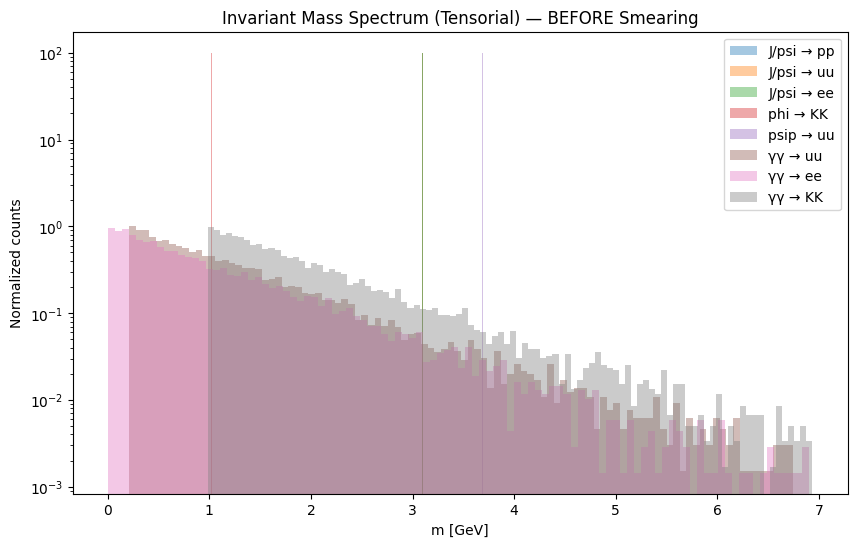

In [11]:
plt.figure(figsize=(10,6))

for name, masses in data_raw1.items():
    plt.hist(masses, bins=100, alpha=0.4, label=name, density=True)

plt.title("Invariant Mass Spectrum (Tensorial) — BEFORE Smearing")
plt.xlabel("m [GeV]")
plt.yscale("log")
plt.ylabel("Normalized counts")
plt.legend()
plt.show()

In [12]:
def smear_event(v, sigma_E=0.02, sigma_p=0.02, sigma_ang=0.001):
    """
    Smear a single event: [E, p, theta, phi]
    """

    E, p, th, ph = v

    # energy and momentum magnitude smearing (Gaussian, fractional)
    E_s = E * np.random.normal(1.0, sigma_E)
    p_s = p * np.random.normal(1.0, sigma_p)

    # angular smearing
    th_s = th + np.random.normal(0.0, sigma_ang)
    ph_s = ph + np.random.normal(0.0, sigma_ang)

    # keep angles physical
    th_s = np.clip(th_s, 0.0, np.pi)
    ph_s = ph_s % (2 * np.pi)

    return np.array([E_s, p_s, th_s, ph_s])

In [13]:
def smear_event_momentum_only(v, mass=0.0, sigma_p=0.02):
    """
    Momentum-based smearing only.

    v = [E, p, theta, phi]
    mass = particle mass (set 0 for ultra-relativistic approximation)
    """

    E, p, th, ph = v

    # convert spherical -> Cartesian momentum
    px = p * np.sin(th) * np.cos(ph)
    py = p * np.sin(th) * np.sin(ph)
    pz = p * np.cos(th)

    p_vec = np.array([px, py, pz])

    # smear each momentum component
    p_vec_s = p_vec * (1.0 + np.random.normal(0.0, sigma_p, size=3))

    # recompute momentum magnitude
    p_s = np.linalg.norm(p_vec_s)

    # avoid division issues
    if p_s == 0:
        return np.array([0.0, 0.0, th, ph])

    # recompute angles
    th_s = np.arccos(np.clip(p_vec_s[2] / p_s, -1.0, 1.0))
    ph_s = np.arctan2(p_vec_s[1], p_vec_s[0])

    # reconstruct energy consistently
    E_s = np.sqrt(p_s**2 + mass**2)

    return np.array([E_s, p_s, th_s, ph_s])

In [14]:
def smear_event_resolution(v, a=0.01, b=0.001):
    """
    Resolution-driven smearing:
    dp/p = a + b p

    v = [E, p, theta, phi]
    """

    E, p, th, ph, m = v

    # resolution
    sigma_p = p * (a + b * p)

    # smear momentum magnitude
    p_s = np.random.normal(p, sigma_p)

    # enforce positivity
    p_s = max(p_s, 0.0)

    # angles unchanged (simple detector model)
    th_s = th
    ph_s = ph

    # reconstruct energy (massless approximation)
    E_s = p_s

    return np.array([E_s, p_s, th_s, ph_s, m])

In [15]:
def smear_event_resolution(v, a=0.01, b=0.001):

    E, p, th, ph, m = v

    sigma_p = p * (a + b * p)

    p_s = np.random.normal(p, sigma_p)
    p_s = max(p_s, 0.0)

    th_s = th
    ph_s = ph

    # correct energy reconstruction
    E_s = np.sqrt(p_s**2 + m**2)

    return np.array([E_s, p_s, th_s, ph_s, m])

In [16]:
def sample_process(generator, N=20000, smear=False):
    masses = []

    for _ in range(N):
        v1, v2 = generator()

        # apply detector smearing AFTER generation
        if smear:
            # v1 = smear_event_momentum_only(v1)
            # v2 = smear_event_momentum_only(v2)

            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)

        masses.append(invariant_mass(v1, v2))

    return np.array(masses)

In [17]:
data_raw2 = {
    name: sample_process(gen, N=10000, smear=False)
    for name, gen in processes.items()
}

In [18]:
data_smeared = {
    name: sample_process(gen, N=10000, smear=True)
    for name, gen in processes.items()
}

In [19]:
def plot_raw_vs_smeared(data_raw, data_smeared, bins=120):
    """
    For each process, plot raw vs smeared invariant mass distributions.
    """
    for name in data_raw.keys():
        raw = data_raw[name]
        smeared = data_smeared[name]

        plt.figure(figsize=(8, 5))

        # Histogram of raw data
        plt.hist(
            raw, bins=bins, density=True, alpha=0.6,
            label=f"{name} (raw)", color="blue"
        )

        # Histogram of smeared data
        plt.hist(
            smeared, bins=bins, density=True, alpha=0.6,
            label=f"{name} (smeared)", color="red"
        )

        # Labels and title
        plt.title(f"Invariant Mass Distribution: {name}")
        plt.xlabel("Invariant Mass [GeV]")
        plt.ylabel("Normalized Counts")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


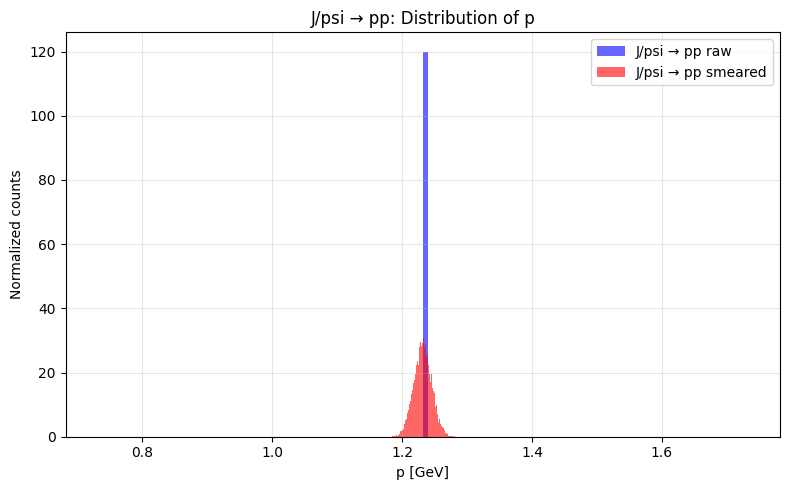

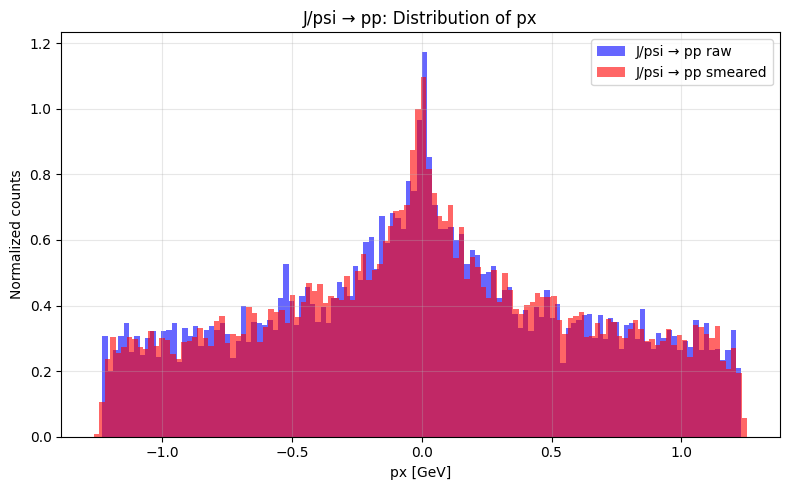

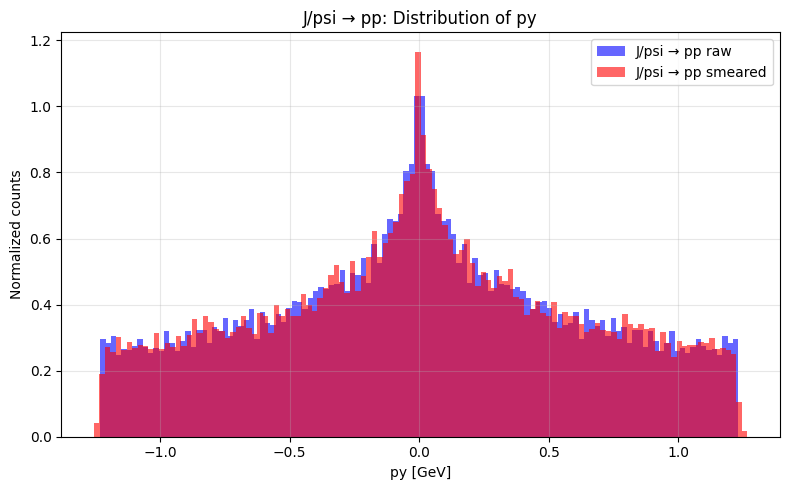

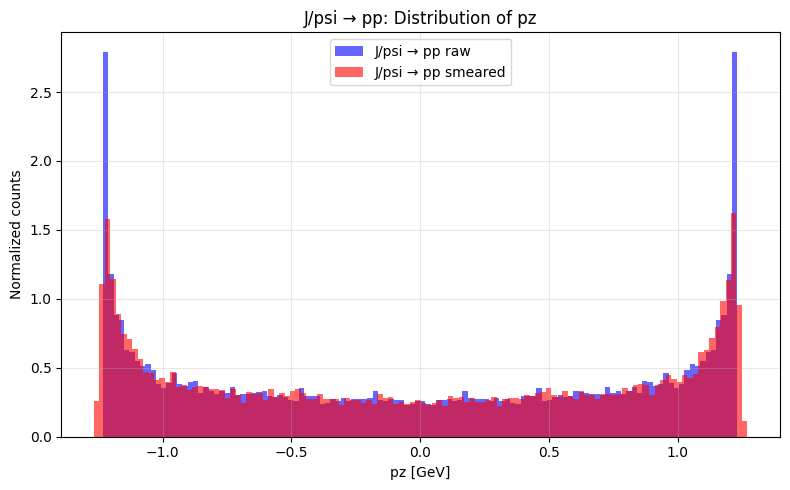

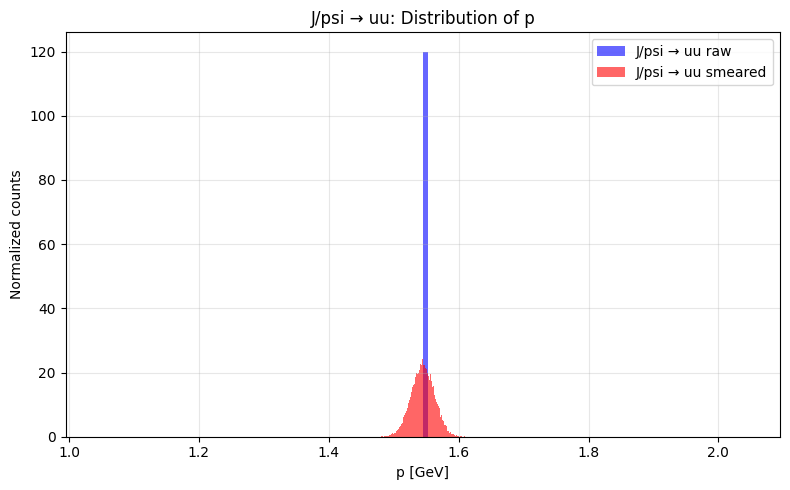

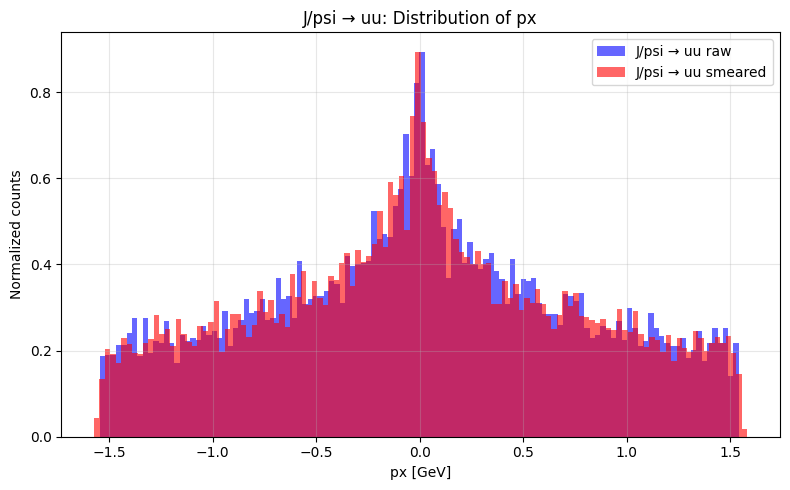

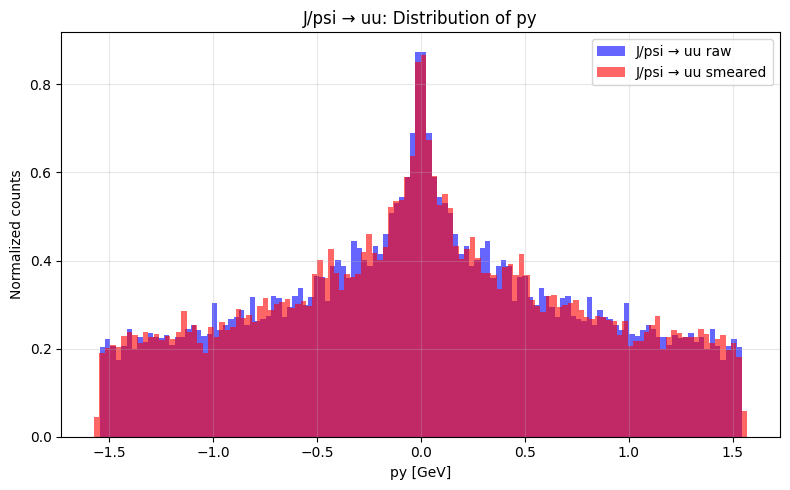

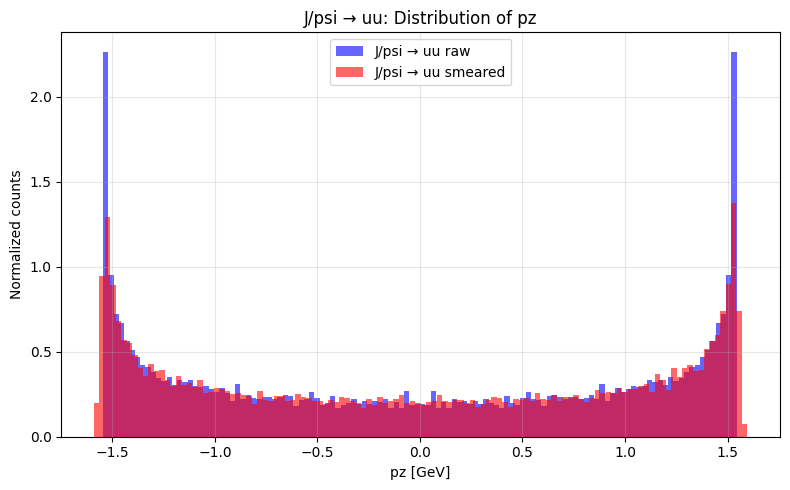

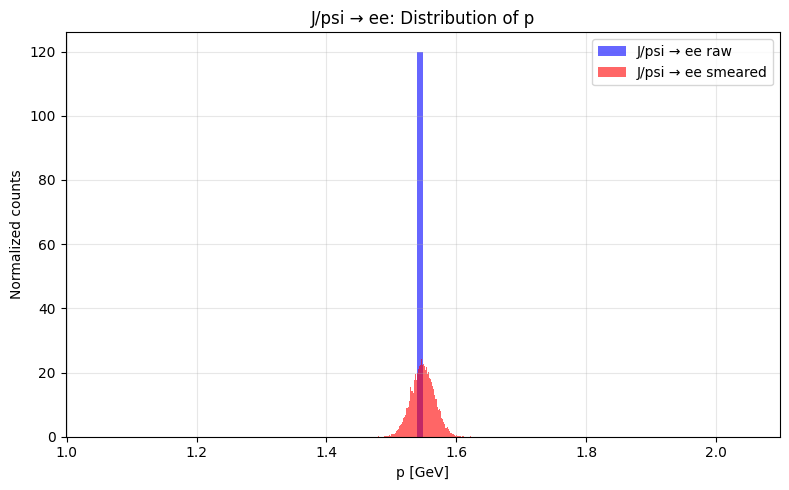

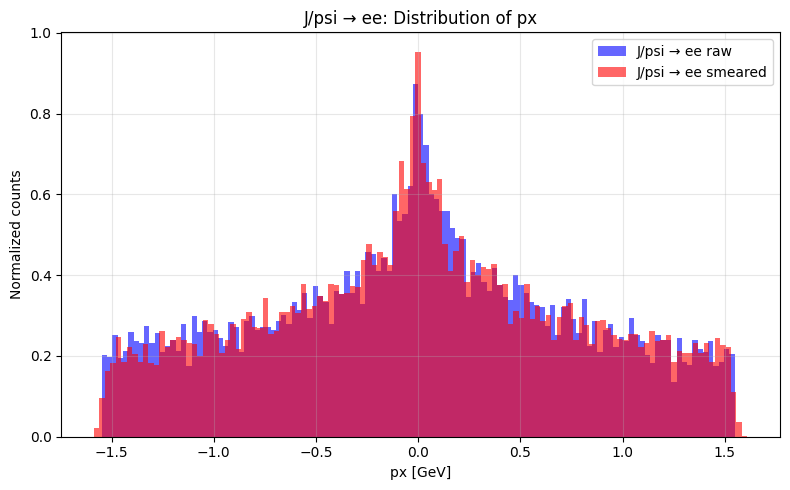

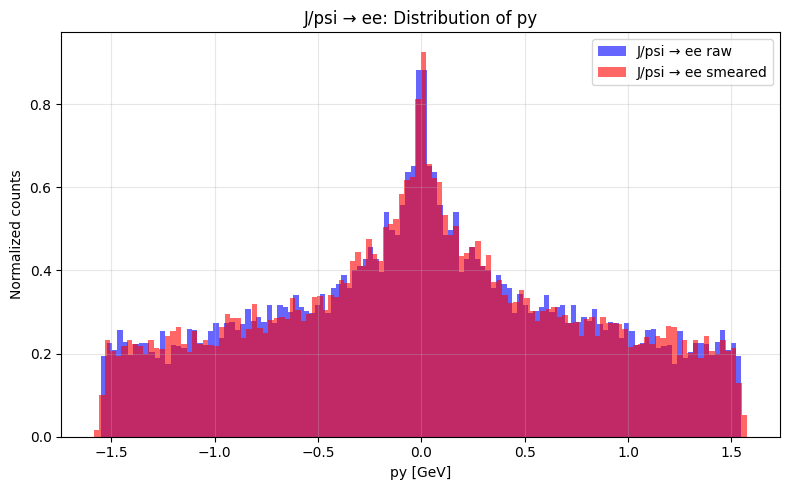

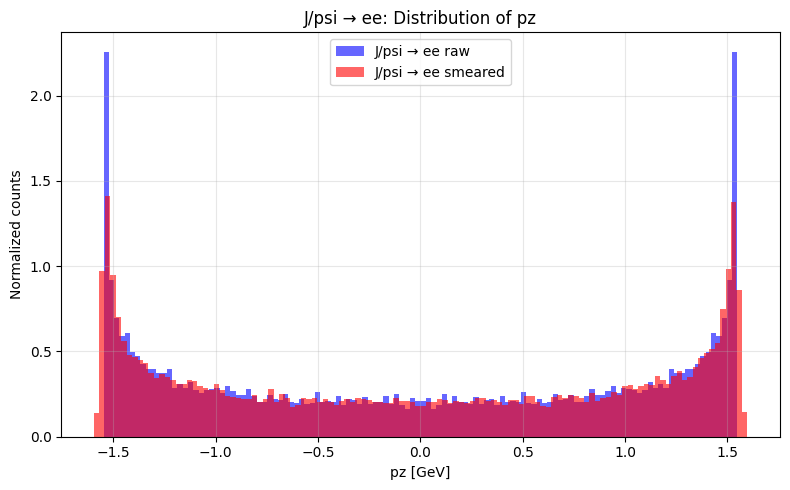

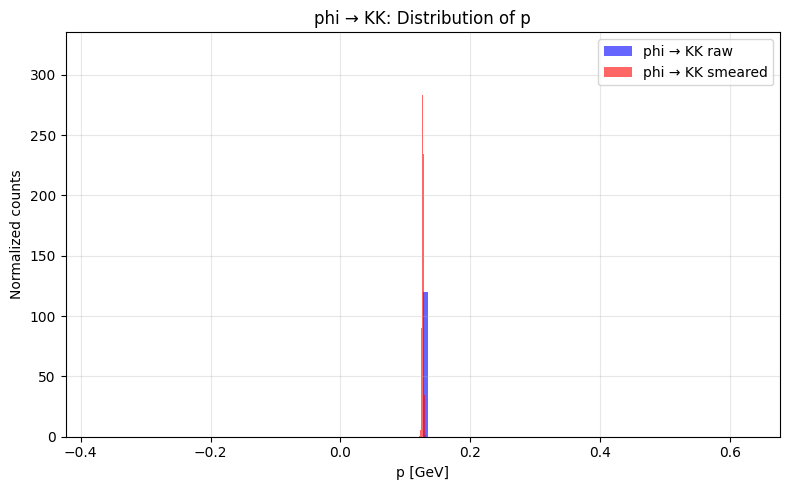

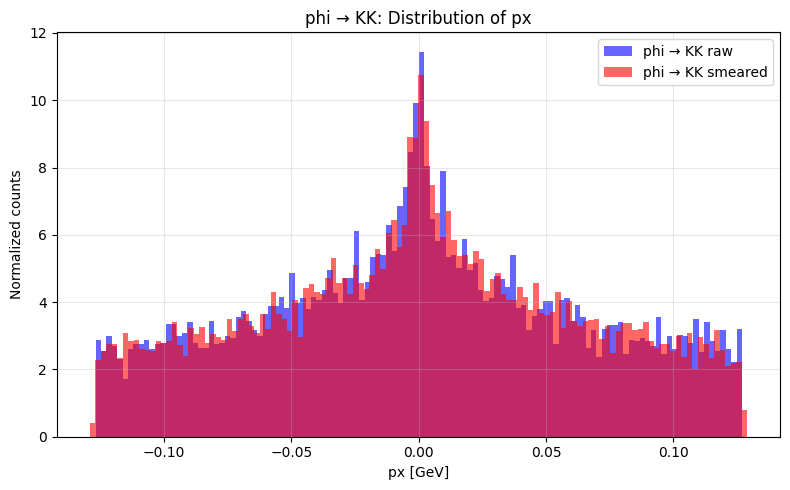

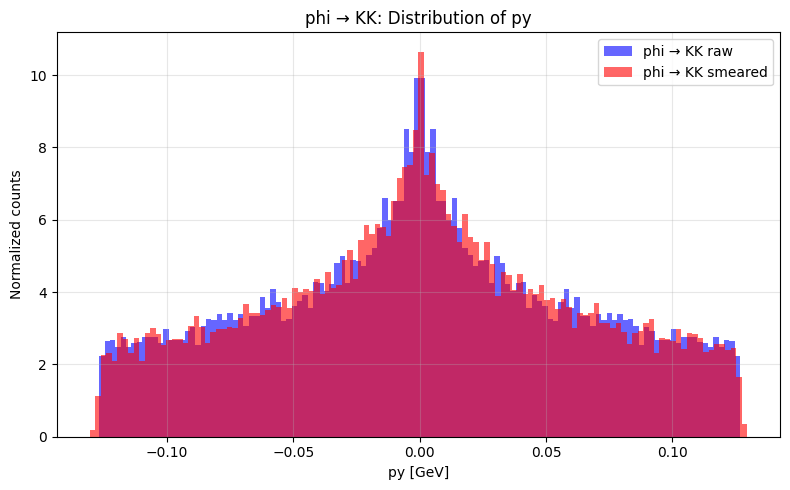

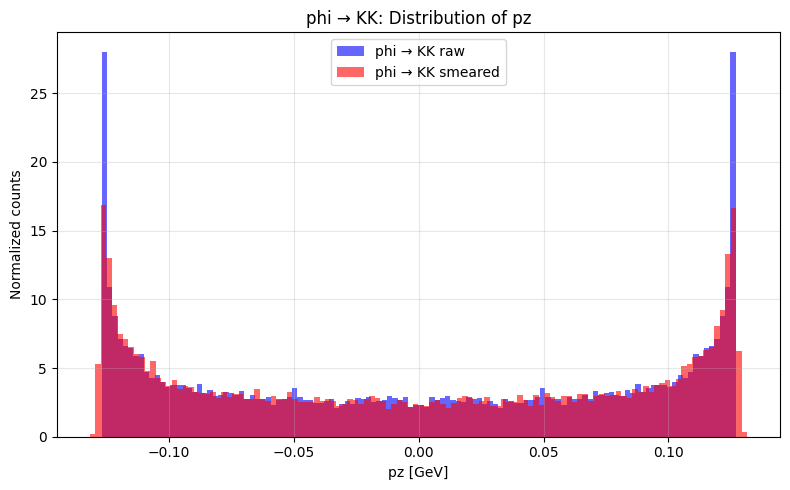

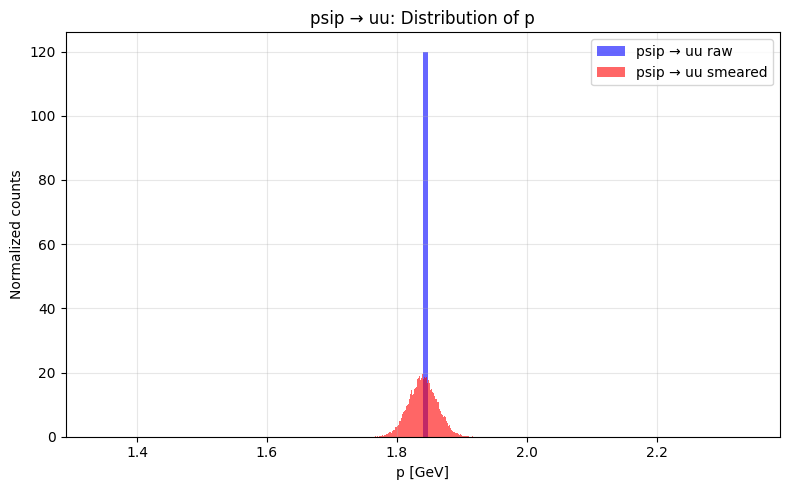

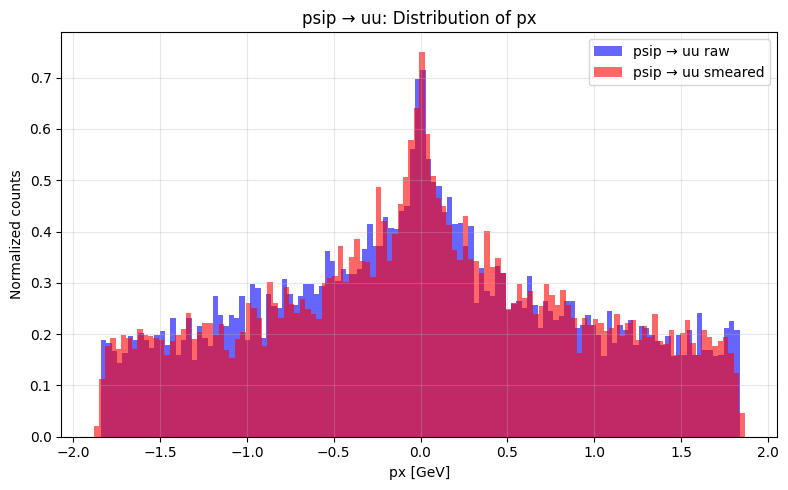

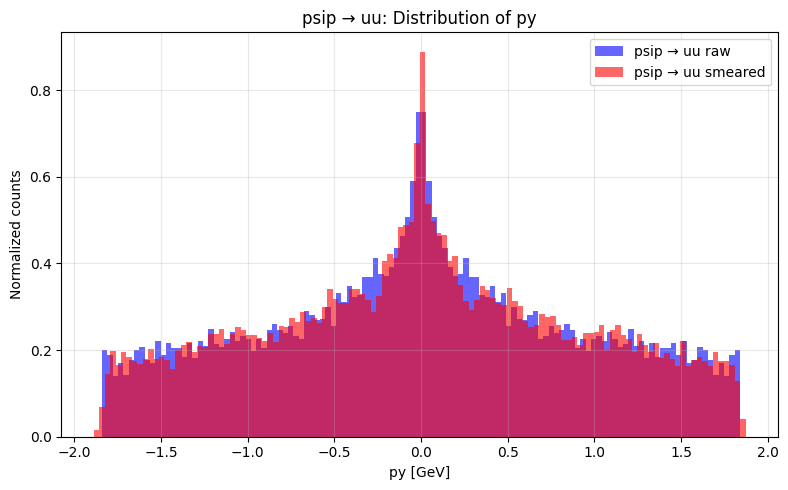

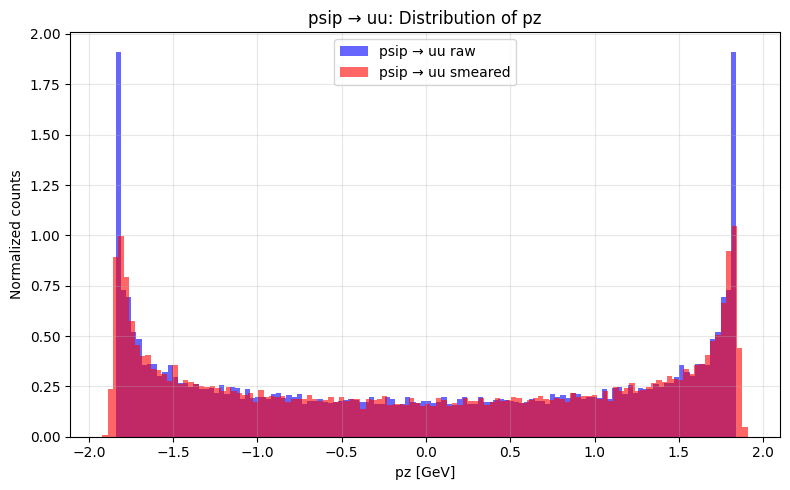

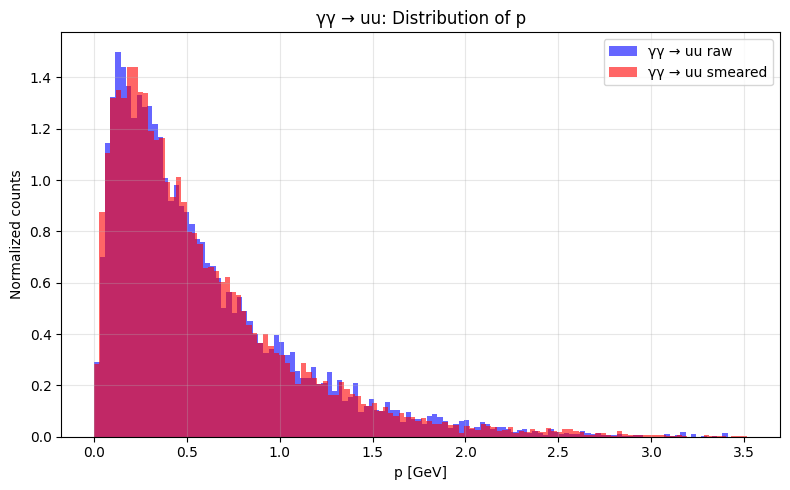

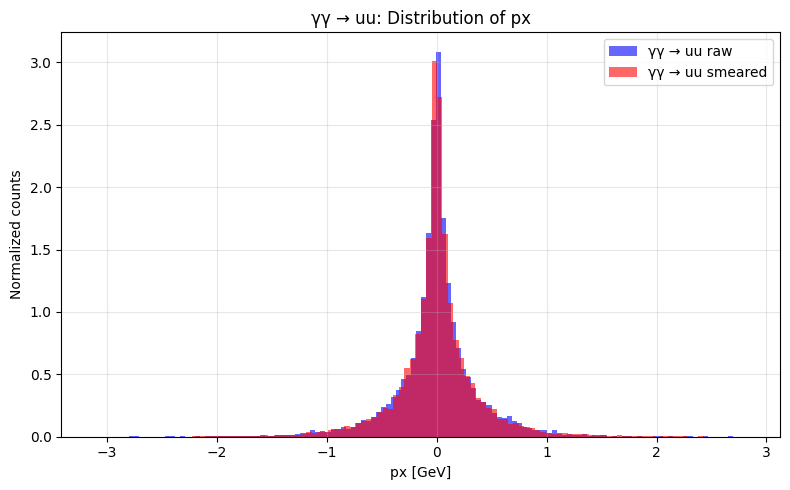

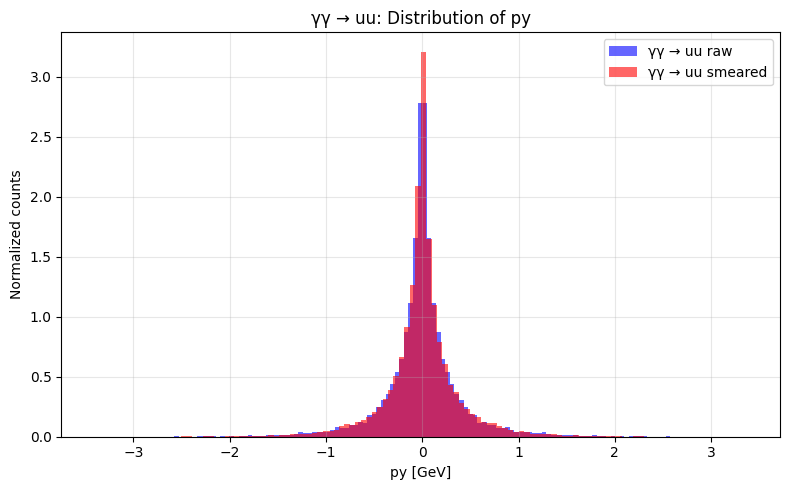

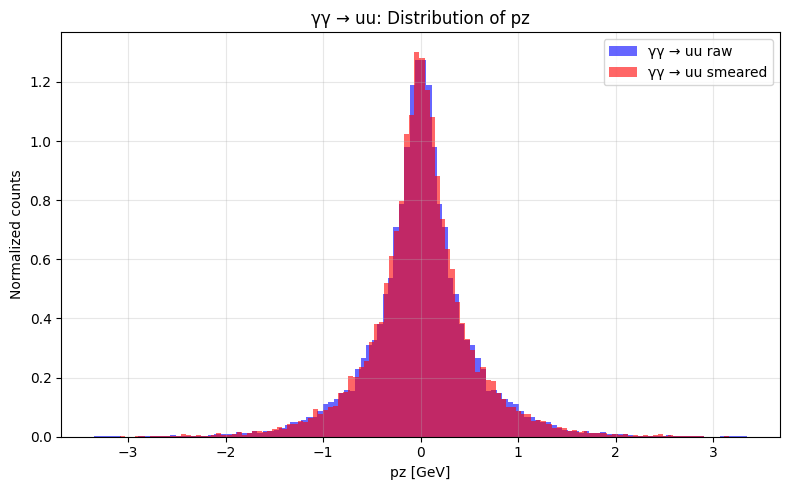

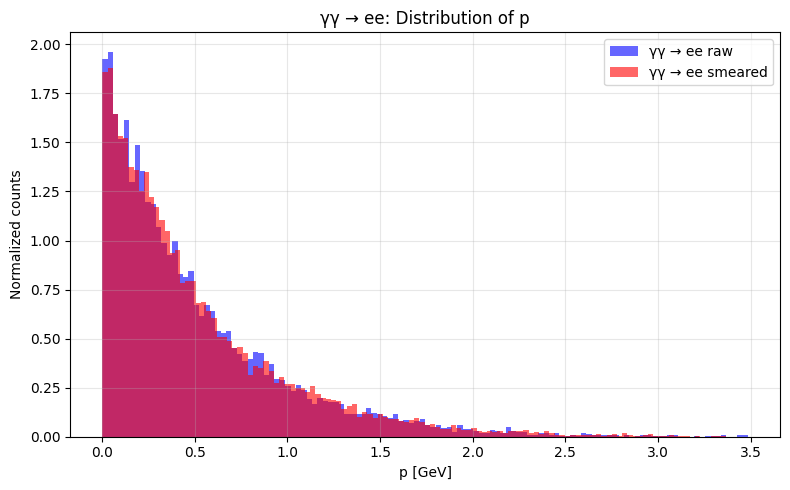

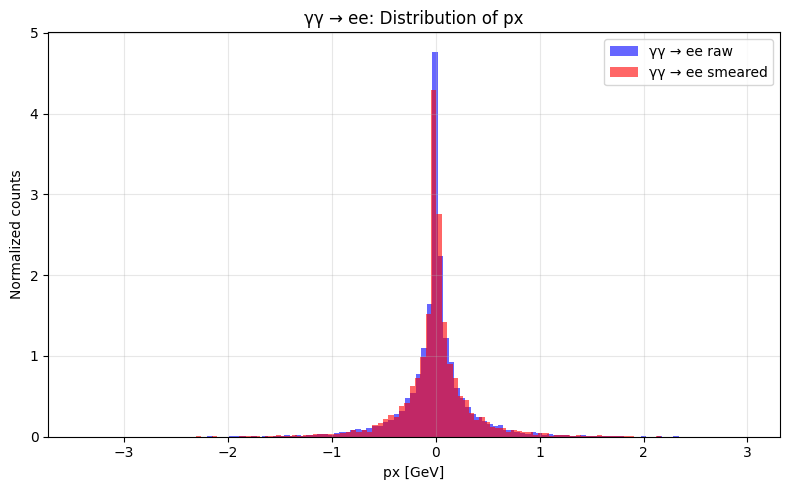

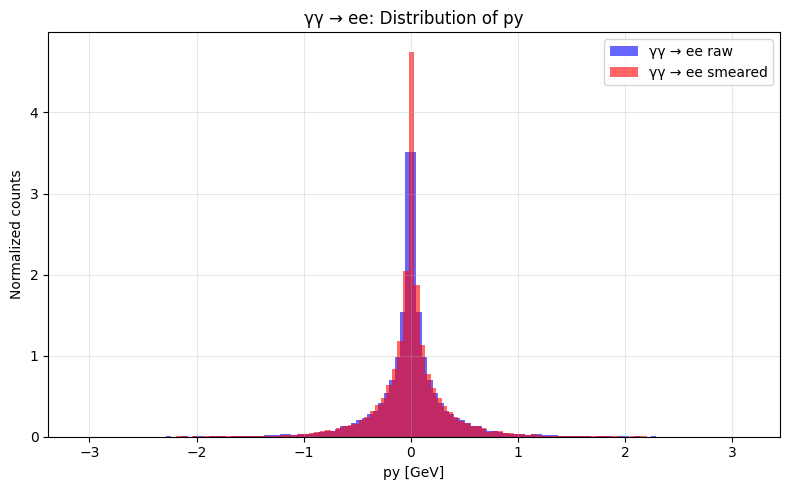

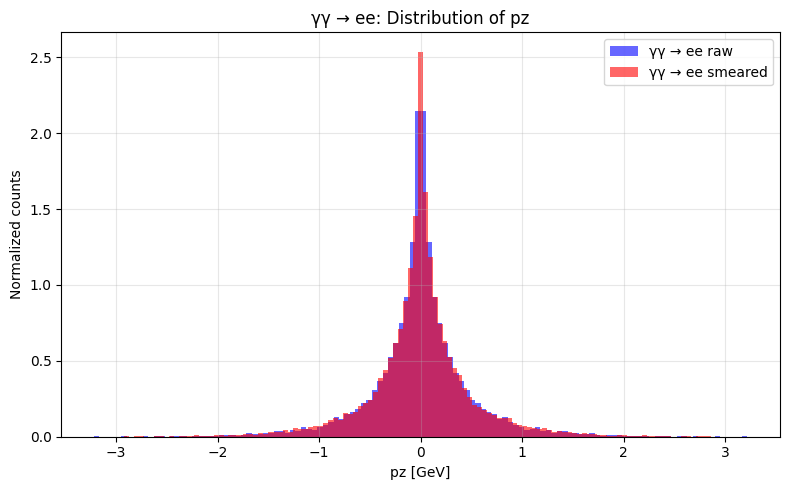

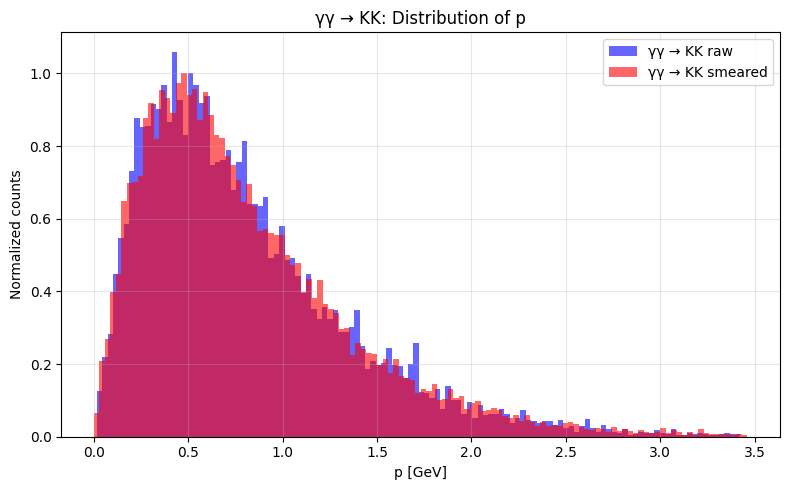

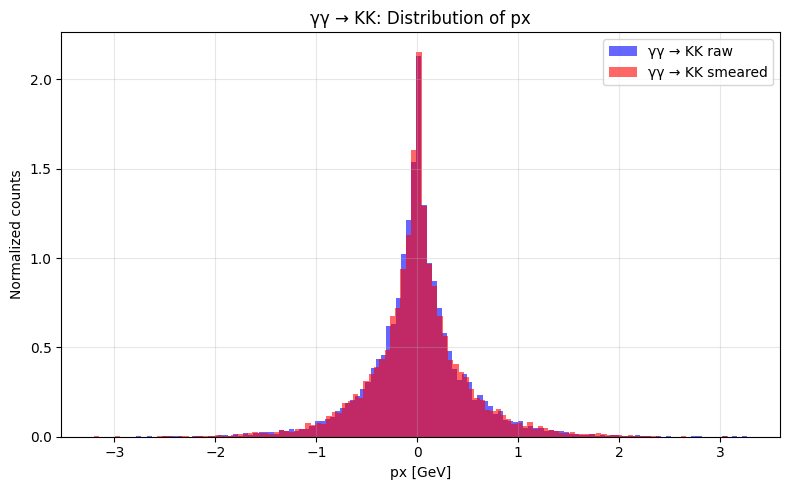

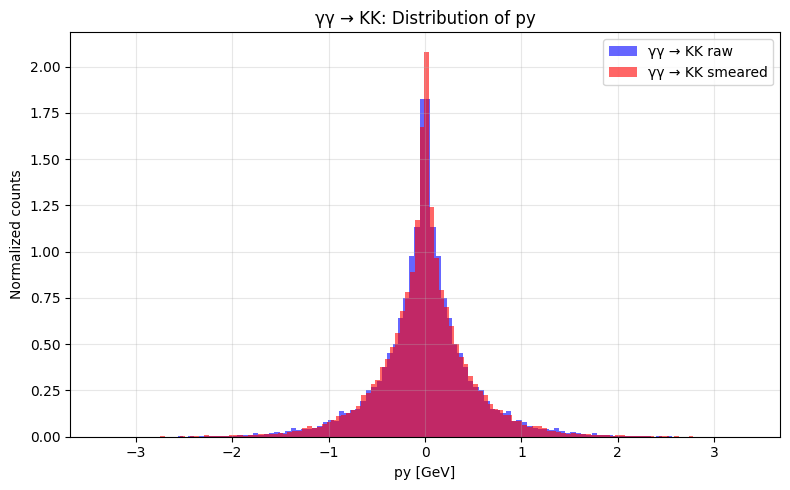

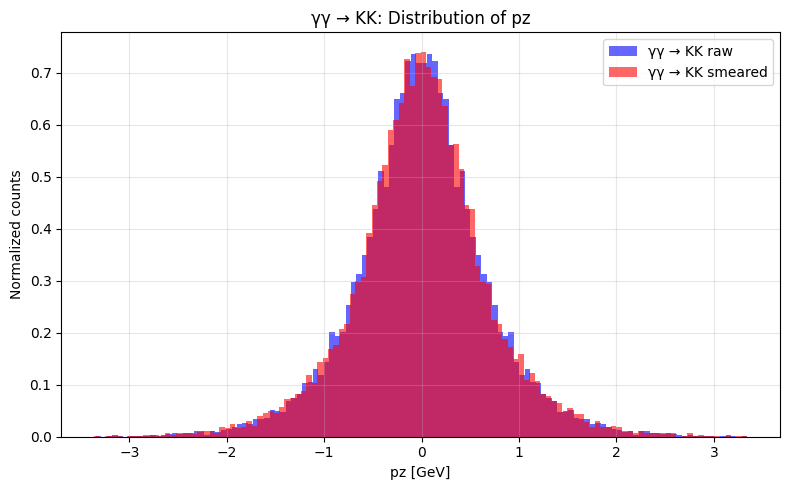

In [20]:
def extract_momentum_components(v):
    """
    v = [E, p, theta, phi, m]
    Returns (p, px, py, pz)
    """
    E, p, th, ph, m = v
    px = p * np.sin(th) * np.cos(ph)
    py = p * np.sin(th) * np.sin(ph)
    pz = p * np.cos(th)
    return p, px, py, pz


def sample_momentum(generator, N=20000, smear=False):
    """
    Collect momentum magnitudes for single tracks.
    Returns arrays for p1, p2.
    """
    p_list = []
    px_list = []
    py_list = []
    pz_list = []

    for _ in range(N):
        v1, v2 = generator()

        if smear:
            v1 = smear_event_resolution(v1)
            v2 = smear_event_resolution(v2)

        # extract momentum components
        for v in (v1, v2):
            p, px, py, pz = extract_momentum_components(v)
            p_list.append(p)
            px_list.append(px)
            py_list.append(py)
            pz_list.append(pz)

    return {
        "p": np.array(p_list),
        "px": np.array(px_list),
        "py": np.array(py_list),
        "pz": np.array(pz_list),
    }


def plot_momentum_distributions(momentum_raw, momentum_smeared, name, bins=120):
    """
    Plot raw vs smeared momentum distributions for a single process.
    """
    for comp in ["p", "px", "py", "pz"]:
        plt.figure(figsize=(8,5))

        plt.hist(momentum_raw[comp], bins=bins, density=True,
                 alpha=0.6, label=f"{name} raw", color="blue")

        plt.hist(momentum_smeared[comp], bins=bins, density=True,
                 alpha=0.6, label=f"{name} smeared", color="red")

        plt.title(f"{name}: Distribution of {comp}")
        plt.xlabel(f"{comp} [GeV]")
        plt.ylabel("Normalized counts")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


# --- RUN FOR ALL PROCESSES ---

momentum_raw_all = {
    name: sample_momentum(gen, N=10000, smear=False)
    for name, gen in processes.items()
}

momentum_smeared_all = {
    name: sample_momentum(gen, N=10000, smear=True)
    for name, gen in processes.items()
}

# Plot for each process
for name in processes.keys():
    plot_momentum_distributions(momentum_raw_all[name],
                                momentum_smeared_all[name],
                                name)

# momentum of single tracks

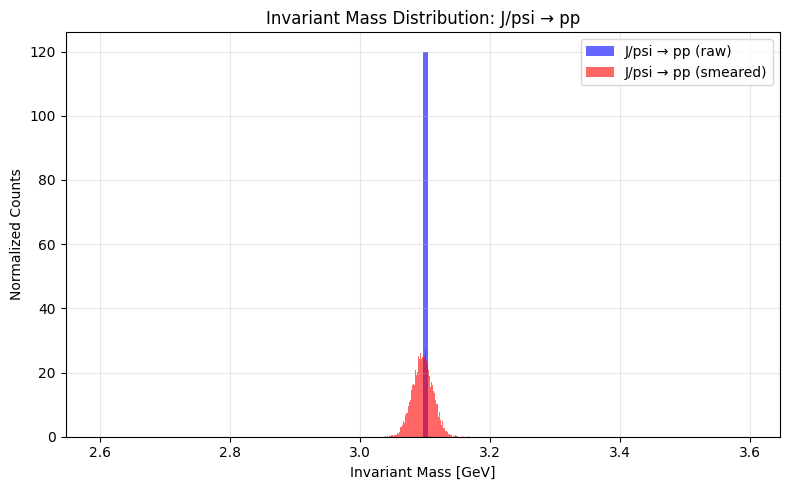

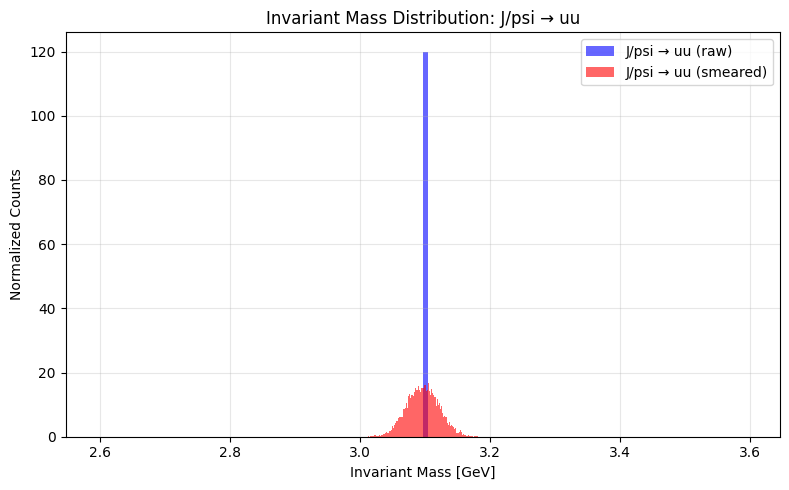

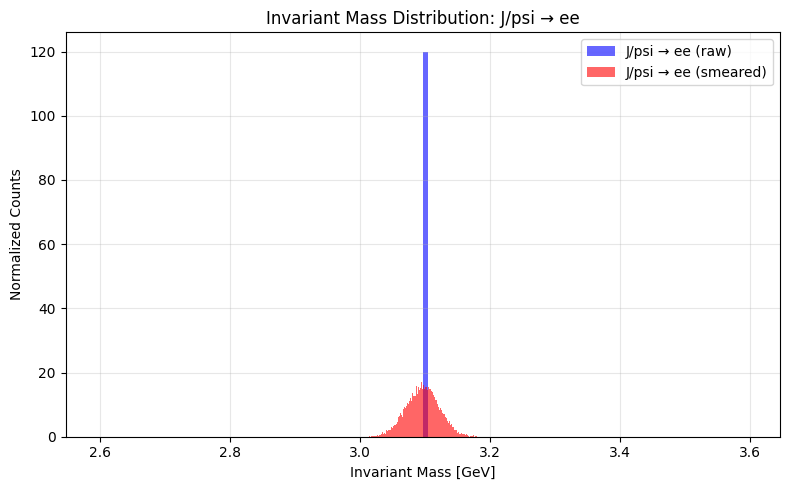

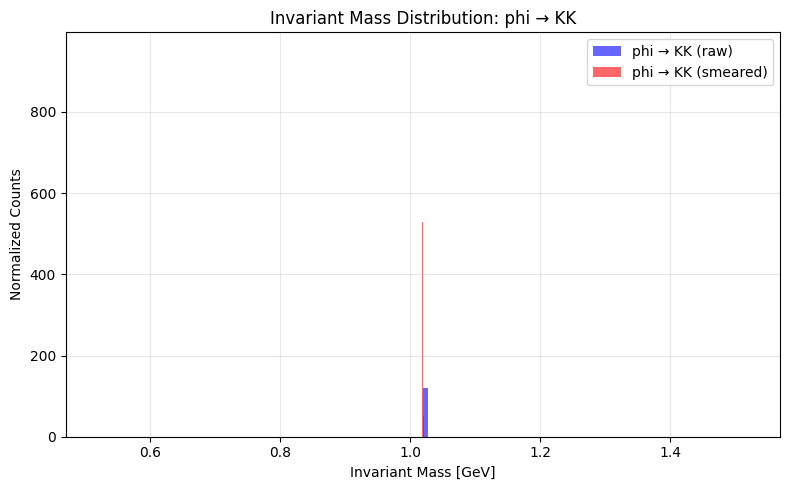

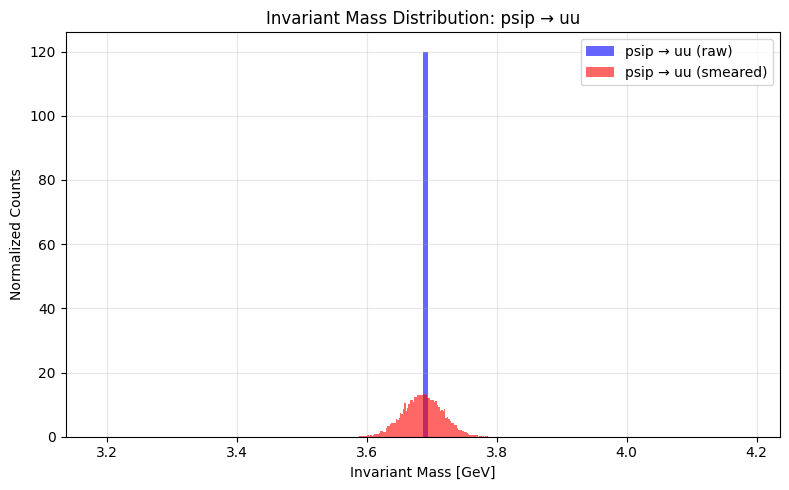

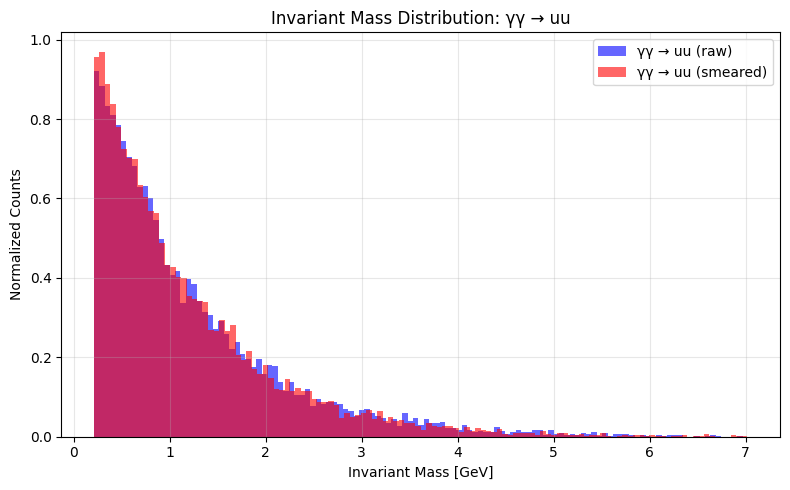

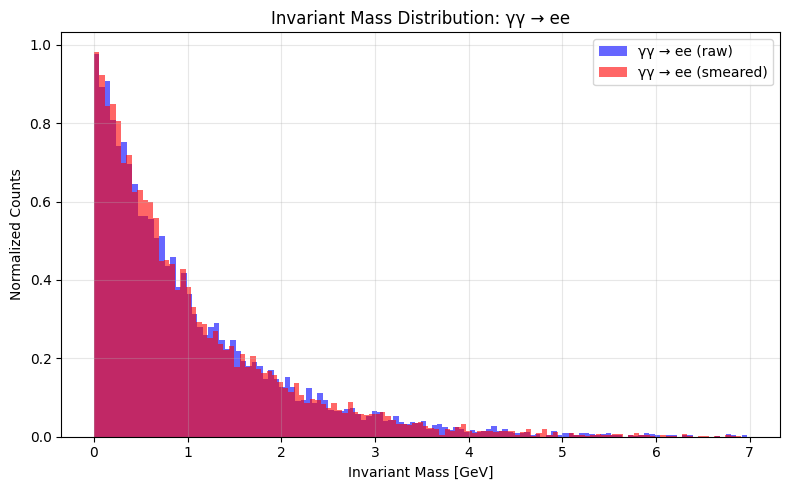

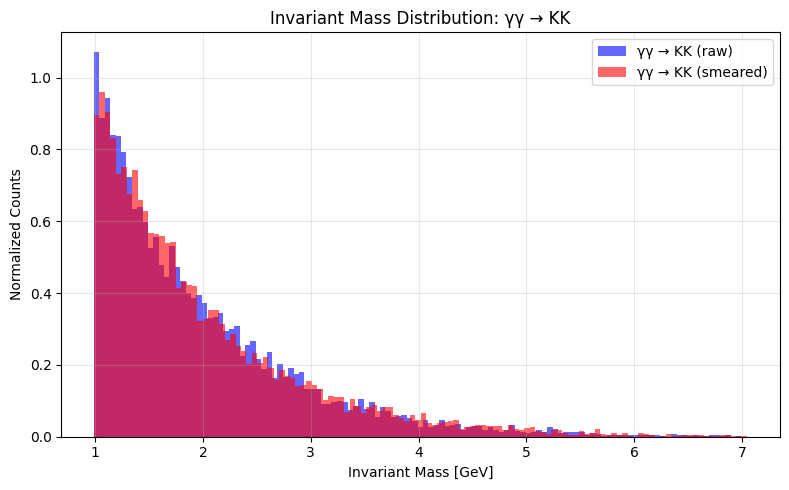

In [21]:
plot_raw_vs_smeared(data_raw2, data_smeared)

In [22]:
def plot_only_smeared(data_smeared, bins=100):
    plt.figure(figsize=(10,6))

    for name, masses in data_smeared.items():
        plt.hist(
            masses,
            bins=bins,
            histtype='step',
            density=True,
            linewidth=1.5,
            label=name
        )

    plt.xlabel("Invariant mass [GeV]")
    plt.ylabel("Normalized counts")
    plt.title("Smeared Invariant Mass Distributions")
    plt.yscale("log")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

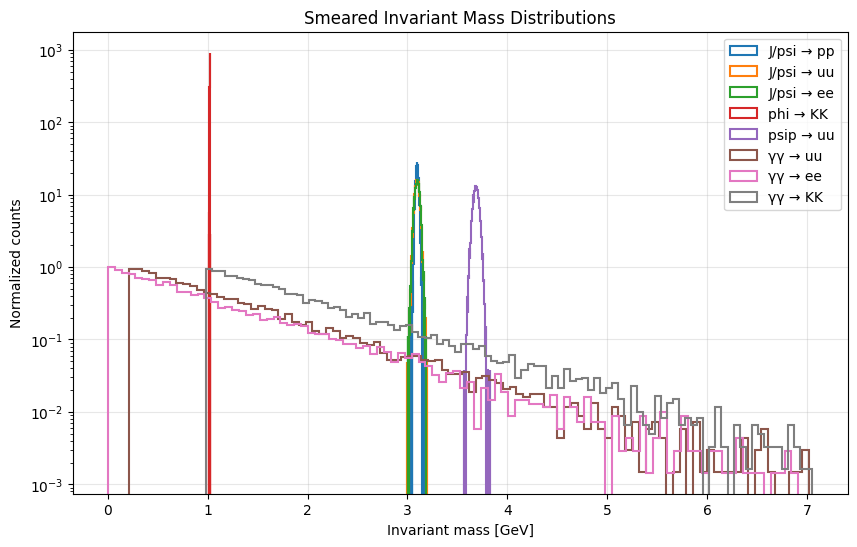

In [23]:
plot_only_smeared(data_smeared)

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def bethe_bloch(momentum, mass, charge=1):
# Constants for Bethe-Bloch approximation
    K = 0.307075 # MeV mol^-1 cm^2
    Z = charge # Particle charge
    I = 0.000016 # Mean excitation potential (MeV)
    m_e = 0.511 # Electron mass in MeV/c^2
    rho = 1 # Density of the material (relative to water, for simplicity)

# Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

# Bethe-Bloch equation (simplified)
    dEdx = ((K * Z**2 * rho) / (beta**2) * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx

def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
    'electron': 0.000511,
    'muon': 0.10566,
    'pion': 0.13957,
    'kaon': 0.49367,
    'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)  # Default to pion mass if not found
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3

    return dEdx, lower_band, upper_band

def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    return upper_band, lower_band

def random_gaussian(mean, sigma):

    return np.random.normal(mean, sigma)

def gaussian_tpc_response(momentum, particle_type, stretch_factor):

    # Get the mean dE/dx from TPC PID response
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type,stretch_factor)

    # Calculate the extremes for the 3σ band
    upper_band, lower_band = error_extremes(momentum, particle_type, stretch_factor)

    # Estimate σ as 1/3rd of the difference between the upper and lower bands
    sigma_dEdx = (upper_band - lower_band) / 6

    # Generate a random dE/dx value from a Gaussian distribution
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)

    return random_dEdx


In [25]:
momentum = .3 # Example momentum in GeV/c
particle_type = 'proton' # Example particle type
x=1000 #Amount of random numbers

rn=[]
for _ in range(x):

    if (particle_type == 'electron'):
        stretch_factor=1
    elif (particle_type == 'muon'):
        stretch_factor=.41
    elif (particle_type == 'pion'):
        stretch_factor=.41
    elif (particle_type == 'kaon'):
        stretch_factor=.38
    elif (particle_type == 'proton'):
        stretch_factor=.40

random_value = gaussian_tpc_response(momentum, particle_type, stretch_factor)
rn.append(random_value)

print(rn)

xvalues=[]
for _ in range(x):
    xvalues.append(momentum)
    print(xvalues)

def plot_tpc_pid_response(momentum_range):
    """
    Plot the TPC PID response and error bands for various particle types.
    """
    # Calculate responses and PID bands for different particle species
    particle_types = {
    'Electron': {'color': 'blue', 'stretch_factor': 1},
    'Muon': {'color': 'orange', 'stretch_factor': 0.41},
    'Pion': {'color': 'red', 'stretch_factor': 0.41},
    'Kaon': {'color': 'green', 'stretch_factor': 0.38},
    'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }


    plt.figure(figsize=(8, 6))

    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
        plt.plot(momentum_range, response, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.2)

    # plt.plot(xvalues,rn, color= 'black')

    plt.xlabel('Momentum (GeV/c)')
    plt.ylabel('dE/dx (arbitrary units)')
    plt.xscale('log')  # Log scale for x-axis
    plt.yscale('log')  # Log scale for y-axis
    plt.title('ALICE TPC PID Response with 3sigma Bands')
    plt.legend()
    plt.grid(True)
    plt.show


[218.31088587681282]
[0.3]
[0.3, 0.3]
[0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3]
[0.3, 0.3,

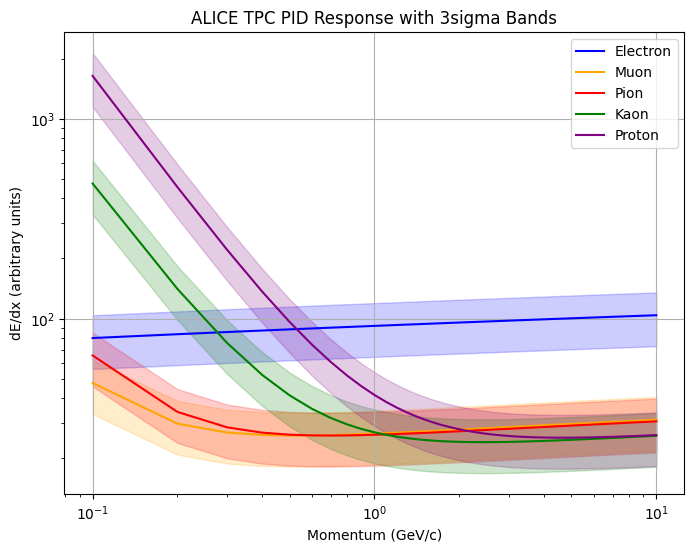

In [26]:

momentum_range = np.linspace(0.1, 10, 100) # Momentum range from 0.1 to 10 GeV/c
plot_tpc_pid_response(momentum_range)




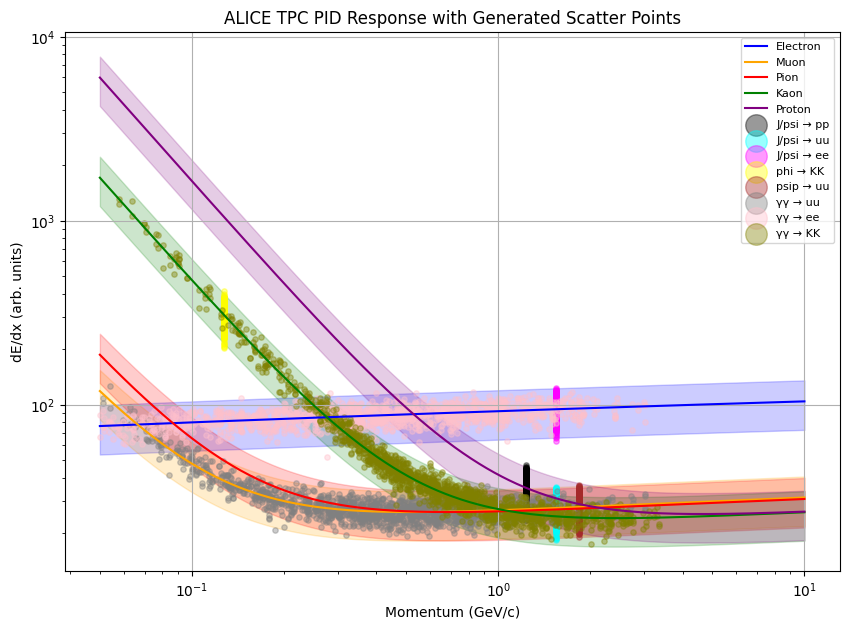

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ============================================================
#  BETHE–BLOCH + TPC RESPONSE
# ============================================================

def bethe_bloch(momentum, mass, charge=1):
    K = 0.307075
    Z = charge
    I = 0.000016
    m_e = 0.511
    rho = 1

    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

    dEdx = ((K * Z**2 * rho) / (beta**2) *
            (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx


def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
        'electron': 0.000511,
        'muon': 0.10566,
        'pion': 0.13957,
        'kaon': 0.49367,
        'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3
    return dEdx, lower_band, upper_band


def error_extremes(momentum, particle_type, stretch_factor):
    _, low, up = tpc_pid_response(momentum, particle_type, stretch_factor)
    return up, low


def random_gaussian(mean, sigma):
    return np.random.normal(mean, sigma)


def gaussian_tpc_response(momentum, particle_type, stretch_factor):
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type, stretch_factor)
    upper, lower = error_extremes(momentum, particle_type, stretch_factor)
    sigma = (upper - lower) / 6
    return random_gaussian(mean_dEdx, sigma)


# ============================================================
#  TWO-BODY GENERATORS
# ============================================================

def p_m1(M, m1, m2):
    return np.sqrt((M**2 - (m1 + m2)**2) * (M**2 - (m1 - m2)**2)) / (2*M)

def E_m1(M, m1, m2):
    return np.sqrt(p_m1(M, m1, m2)**2 + m1**2)

def generate_two_body(M, m1, m2):
    theta = random.uniform(0, 2*np.pi)
    phi = random.uniform(0, np.pi)

    theta2 = (np.pi + theta) % (2*np.pi)
    phi2 = np.pi - phi

    E1 = E_m1(M, m1, m2)
    E2 = E_m1(M, m2, m1)

    p1 = p_m1(M, m1, m2)
    p2 = p_m1(M, m2, m1)

    v1 = np.array([E1, p1, theta, phi, m1])
    v2 = np.array([E2, p2, theta2, phi2, m2])

    return v1, v2


# ============================================================
#  MASSES
# ============================================================

M_JPSI = 3.0969
M_PHI = 1.01946
M_PSIP = 3.686
M_P = 0.93827
M_U = 0.10566
M_E = 0.000511
M_K = 0.493677

def generate_Jpsi_pp(): return generate_two_body(M_JPSI, M_P, M_P)
def generate_Jpsi_uu(): return generate_two_body(M_JPSI, M_U, M_U)
def generate_Jpsi_ee(): return generate_two_body(M_JPSI, M_E, M_E)
def generate_phi_kk(): return generate_two_body(M_PHI, M_K, M_K)
def generate_psip_uu(): return generate_two_body(M_PSIP, M_U, M_U)

# ============================================================
#  VARIABLE MASS GAMMA-GAMMA
# ============================================================

def sample_exponential_truncated(m_min, m_max, scale):
    while True:
        x = np.random.exponential(scale=scale)
        if m_min <= x <= m_max:
            return x

def generate_two_body_varmass(mass, m1):
    return generate_two_body(mass, m1, m1)

def generate_gammagamma_uu():
    M = sample_exponential_truncated(2*M_U, 7, 1)
    return generate_two_body_varmass(M, M_U)

def generate_gammagamma_ee():
    M = sample_exponential_truncated(2*M_E, 7, 1)
    return generate_two_body_varmass(M, M_E)

def generate_gammagamma_kk():
    M = sample_exponential_truncated(2*M_K, 7, 1)
    return generate_two_body_varmass(M, M_K)


# ============================================================
#  PROCESS DICTIONARY
# ============================================================

processes = {
    "J/psi → pp": generate_Jpsi_pp,
    "J/psi → uu": generate_Jpsi_uu,
    "J/psi → ee": generate_Jpsi_ee,
    "phi → KK": generate_phi_kk,
    "psip → uu": generate_psip_uu,
    "γγ → uu": generate_gammagamma_uu,
    "γγ → ee": generate_gammagamma_ee,
    "γγ → KK": generate_gammagamma_kk,
}

# ============================================================
#  SCATTER POINT GENERATION FOR TPC PLOT
# ============================================================

def particle_type_from_mass(m):
    if abs(m - M_E) < 1e-3: return "electron"
    if abs(m - M_U) < 1e-3: return "muon"
    if abs(m - M_K) < 1e-3: return "kaon"
    if abs(m - M_P) < 1e-3: return "proton"
    return "pion"


def stretch_factor_for(particle):
    return {
        "electron": 1,
        "muon": 0.41,
        "pion": 0.41,
        "kaon": 0.38,
        "proton": 0.40
    }[particle]


def generate_scatter_points(generator, momentum_range, N=2000):
    momenta = []
    dEdx_vals = []

    minval = min(momentum_range)
    maxval = max(momentum_range)
    for _ in range(N):
        v1, v2 = generator()
    
        for v in (v1, v2):
            E, p, th, ph, m = v
            if p < minval:
                continue
            if p > maxval:
                continue
            particle = particle_type_from_mass(m)
            sf = stretch_factor_for(particle)

            dEdx = gaussian_tpc_response(p, particle, sf)

            momenta.append(p)
            dEdx_vals.append(dEdx)

    return np.array(momenta), np.array(dEdx_vals)


# ============================================================
#  PLOTTER
# ============================================================

def plot_tpc_with_scatter(momenta_range):
    momentum_range = momenta_range

    particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(10, 7))

    # PID bands
    for particle, settings in particle_types.items():
        resp, low, up = tpc_pid_response(
            momentum_range, particle.lower(), settings['stretch_factor']
        )
        plt.plot(momentum_range, resp, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, low, up, color=settings['color'], alpha=0.2)

    # Scatter points from generators
    colors = ["black", "cyan", "magenta", "yellow", "brown", "gray", "pink", "olive"]

    for (name, gen), col in zip(processes.items(), colors):
        pvals, dvals = generate_scatter_points(gen, momentum_range, N=800)
        plt.scatter(pvals, dvals, s=15, alpha=0.4, label=name, color=col)

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Momentum (GeV/c)")
    plt.ylabel("dE/dx (arb. units)")
    plt.title("ALICE TPC PID Response with Generated Scatter Points")
    plt.legend(markerscale=4, fontsize=8)
    plt.grid(True)
    plt.show()


# ============================================================
#  RUN
# ============================================================
momentum_range = np.linspace(0.05, 10, 2000)
plot_tpc_with_scatter(momentum_range)


TABLE

In [31]:
import numpy as np
import pandas as pd
import random

# ============================================================
#  BETHE–BLOCH + TPC RESPONSE
# ============================================================

def bethe_bloch(momentum, mass, charge=1):
    K = 0.307075
    Z = charge
    I = 0.000016
    m_e = 0.511
    rho = 1

    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

    dEdx = ((K * Z**2 * rho) / (beta**2) *
            (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx


def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
        'electron': 0.000511,
        'muon': 0.10566,
        'pion': 0.13957,
        'kaon': 0.49367,
        'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3
    return dEdx, lower_band, upper_band


def gaussian_tpc_response(momentum, particle_type, stretch_factor):
    mean, low, up = tpc_pid_response(momentum, particle_type, stretch_factor)
    sigma = (up - low) / 6
    return np.random.normal(mean, sigma), sigma


# ============================================================
#  TWO-BODY GENERATORS
# ============================================================

def p_m1(M, m1, m2):
    return np.sqrt((M**2 - (m1 + m2)**2) * (M**2 - (m1 - m2)**2)) / (2*M)

def E_m1(M, m1, m2):
    return np.sqrt(p_m1(M, m1, m2)**2 + m1**2)

def generate_two_body(M, m1, m2):
    theta = random.uniform(0, np.pi)
    phi = random.uniform(0, 2*np.pi)

    p = p_m1(M, m1, m2)
    E = E_m1(M, m1, m2)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    v1 = np.array([E, px, py, pz, m1])

    # second particle opposite direction
    v2 = np.array([E, -px, -py, -pz, m2])

    return v1, v2


# ============================================================
#  MASSES
# ============================================================

M_JPSI = 3.0969
M_PHI = 1.01946
M_PSIP = 3.686
M_P = 0.93827
M_U = 0.10566
M_E = 0.000511
M_K = 0.493677

def generate_Jpsi_pp(): return generate_two_body(M_JPSI, M_P, M_P)
def generate_Jpsi_uu(): return generate_two_body(M_JPSI, M_U, M_U)
def generate_Jpsi_ee(): return generate_two_body(M_JPSI, M_E, M_E)
def generate_phi_kk(): return generate_two_body(M_PHI, M_K, M_K)
def generate_psip_uu(): return generate_two_body(M_PSIP, M_U, M_U)


# ============================================================
#  PID HELPERS
# ============================================================

def particle_type_from_mass(m):
    if abs(m - M_E) < 1e-3: return "electron"
    if abs(m - M_U) < 1e-3: return "muon"
    if abs(m - M_K) < 1e-3: return "kaon"
    if abs(m - M_P) < 1e-3: return "proton"
    return "pion"

def stretch_factor_for(particle):
    return {
        "electron": 1,
        "muon": 0.41,
        "pion": 0.41,
        "kaon": 0.38,
        "proton": 0.40
    }[particle]


# ============================================================
#  TABLE GENERATOR
# ============================================================

def generate_pid_table(generator, N=2000):
    rows = []

    species = ["electron", "muon", "pion", "kaon", "proton"]

    for _ in range(N):
        v1, v2 = generator()

        for v in (v1, v2):
            E, px, py, pz, m = v
            p = np.sqrt(px**2 + py**2 + pz**2)

            if p < 0.1:
                continue

            ptype = particle_type_from_mass(m)
            sf = stretch_factor_for(ptype)

            dEdx_meas, sigma_self = gaussian_tpc_response(p, ptype, sf)

            # compute Nσ for each species
            nsig = {}
            for sp in species:
                mean, low, up = tpc_pid_response(p, sp, stretch_factor_for(sp))
                sigma = (up - low) / 6
                nsig[sp] = (dEdx_meas - mean) / sigma

            rows.append({
                "ptype": ptype,
                "px": px,
                "py": py,
                "pz": pz,
                "p": p,
                "E": E,
                "dEdx_meas": dEdx_meas,
                **{f"nsigma_{sp}": nsig[sp] for sp in species}
            })

    return pd.DataFrame(rows)


# ============================================================
#  RUN EXAMPLE
# ============================================================

df = generate_pid_table(generate_Jpsi_pp, N=5000)
print(df.head())


    ptype        px        py        pz         p        E  dEdx_meas  \
0  proton -0.250078 -0.374347 -1.146591  1.231806  1.54845  36.115881   
1  proton  0.250078  0.374347  1.146591  1.231806  1.54845  35.519151   
2  proton -0.627747 -0.899195  0.561008  1.231806  1.54845  37.287402   
3  proton  0.627747  0.899195 -0.561008  1.231806  1.54845  42.190083   
4  proton -0.181829 -1.006477  0.686504  1.231806  1.54845  33.097761   

   nsigma_electron  nsigma_muon  nsigma_pion  nsigma_kaon  nsigma_proton  
0        -6.122291     3.382369     3.606686     4.123851       0.235970  
1        -6.186361     3.161257     3.381868     3.890487       0.066844  
2        -5.996507     3.816464     4.048058     4.581997       0.568002  
3        -5.470113     5.633102     5.895147     6.499291       1.957521  
4        -6.446342     2.264036     2.469607     2.943553      -0.619427  


In [29]:
import numpy as np
import pandas as pd
import random

# ------------------------------------------------------------
#  EVENT-BASED TABLE FOR AUTOENCODER
# ------------------------------------------------------------

def build_event_table(generator, process_name, N=5000):
    rows = []
    event_id = 0

    species = ["electron", "muon", "pion", "kaon", "proton"]

    for _ in range(N):
        v1, v2 = generator()

        event_row = {"event_id": event_id, "process": process_name}

        for i, v in enumerate((v1, v2), start=1):
            E, px, py, pz, m = v
            p = np.sqrt(px**2 + py**2 + pz**2)

            if p < 0.1:
                continue

            ptype = particle_type_from_mass(m)
            sf = stretch_factor_for(ptype)

            dEdx_meas, sigma_self = gaussian_tpc_response(p, ptype, sf)

            # Fill kinematics
            event_row[f"ptype{i}"] = ptype
            event_row[f"px{i}"] = px
            event_row[f"py{i}"] = py
            event_row[f"pz{i}"] = pz
            event_row[f"p{i}"] = p
            event_row[f"E{i}"] = E
            event_row[f"dEdx{i}"] = dEdx_meas

            # Fill Nσ values
            for sp in species:
                mean, low, up = tpc_pid_response(p, sp, stretch_factor_for(sp))
                sigma = (up - low) / 6
                nsigma = (dEdx_meas - mean) / sigma
                event_row[f"nsigma_{sp}_{i}"] = nsigma

        rows.append(event_row)
        event_id += 1

    return pd.DataFrame(rows)


In [30]:
df_events = build_event_table(generate_Jpsi_pp, "J/psi → pp", N=2000)
print(df_events.head())


   event_id     process  ptype1       px1       py1       pz1        p1  \
0         0  J/psi → pp  proton -0.412995 -0.040673  1.159796  1.231806   
1         1  J/psi → pp  proton -0.796403 -0.877827  0.335424  1.231806   
2         2  J/psi → pp  proton  0.418643  0.468963  1.059320  1.231806   
3         3  J/psi → pp  proton  0.028571  0.871101 -0.870467  1.231806   
4         4  J/psi → pp  proton -0.184899  0.763541 -0.948770  1.231806   

        E1      dEdx1  nsigma_electron_1  ...       py2       pz2        p2  \
0  1.54845  39.676682          -5.739973  ...  0.040673 -1.159796  1.231806   
1  1.54845  36.643535          -6.065638  ...  0.877827 -0.335424  1.231806   
2  1.54845  38.453671          -5.871286  ... -0.468963 -1.059320  1.231806   
3  1.54845  27.260571          -7.073073  ... -0.871101  0.870467  1.231806   
4  1.54845  33.611865          -6.391144  ... -0.763541  0.948770  1.231806   

        E2      dEdx2  nsigma_electron_2  nsigma_muon_2  nsigma_pion_2  \


TABLE
Ragoni ai based
